In [63]:
import pandas as pd

In [64]:
df=pd.read_csv('dataset/babies.csv')
df.head()

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   case       1236 non-null   int64  
 1   bwt        1236 non-null   int64  
 2   gestation  1223 non-null   float64
 3   parity     1236 non-null   int64  
 4   age        1234 non-null   float64
 5   height     1214 non-null   float64
 6   weight     1200 non-null   float64
 7   smoke      1226 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 77.4 KB


In [66]:
df.describe()

,case,bwt,gestation,parity,age,height,weight,smoke
count,1236.000000,1236.000000,1223.000000,1236.000000,1234.000000,1214.000000,1200.000000,1226.000000
mean,618.500000,119.576861,279.338512,0.254854,27.255267,64.047776,128.625833,0.394780
std,356.946775,18.236452,16.027693,0.435956,5.781405,2.533409,20.971862,0.489003
min,1.000000,55.000000,148.000000,0.000000,15.000000,53.000000,87.000000,0.000000
25%,309.750000,108.750000,272.000000,0.000000,23.000000,62.000000,114.750000,0.000000
50%,618.500000,120.000000,280.000000,0.000000,26.000000,64.000000,125.000000,0.000000
75%,927.250000,131.000000,288.000000,1.000000,31.000000,66.000000,139.000000,1.000000
max,1236.000000,176.000000,353.000000,1.000000,45.000000,72.000000,250.000000,1.000000


In [67]:
 #* finding the missing values

df.isnull().sum()

case          0
bwt           0
gestation    13
parity        0
age           2
height       22
weight       36
smoke        10
dtype: int64

In [68]:
 # *REMOVING MISSING VALUES

df.dropna(inplace=True)

In [69]:
df.isnull().sum()

case         0
bwt          0
gestation    0
parity       0
age          0
height       0
weight       0
smoke        0
dtype: int64

In [70]:
 #  *Checking duplicate values

print(df.duplicated().sum())

0


In [71]:
import matplotlib.pyplot as plt

In [72]:
df.columns

Index(['case', 'bwt', 'gestation', 'parity', 'age', 'height', 'weight',
       'smoke'],
      dtype='object')

In [73]:
 #* Removing the 'case' column as it is not required for model training 
df.drop(columns='case', inplace=True)


In [74]:
df.columns

Index(['bwt', 'gestation', 'parity', 'age', 'height', 'weight', 'smoke'], dtype='object')

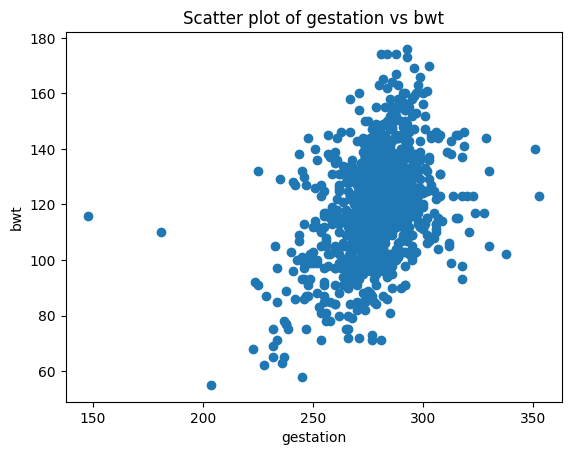

In [75]:
plt.scatter(df['gestation'],df['bwt'])
plt.xlabel('gestation')
plt.ylabel('bwt')
plt.title('Scatter plot of gestation vs bwt')
plt.show()

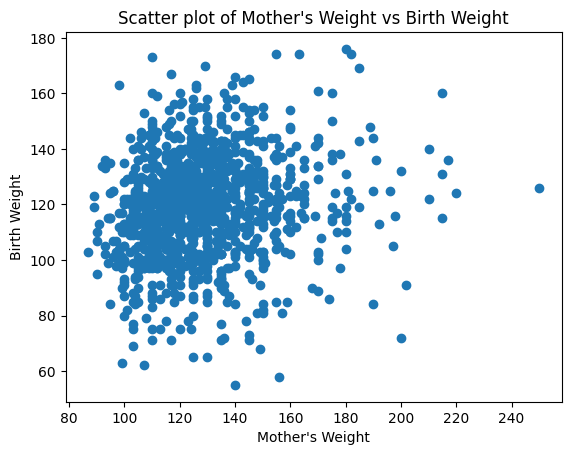

In [76]:
plt.scatter(df['weight'],df['bwt'])
plt.xlabel("Mother's Weight")
plt.ylabel("Birth Weight")
plt.title("Scatter plot of Mother's Weight vs Birth Weight")
plt.show()

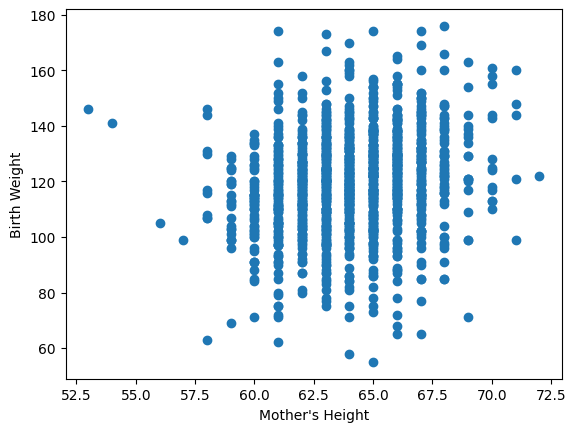

In [77]:
plt.scatter(df['height'] , df['bwt'])
plt.xlabel("Mother's Height")
plt.ylabel("Birth Weight")
plt.show()

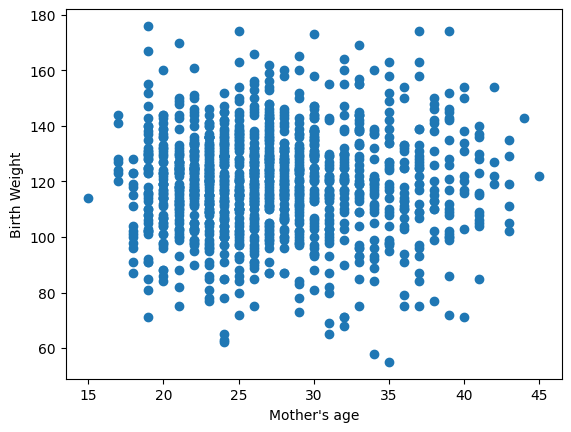

In [78]:
plt.scatter(df['age'] , df['bwt'])
plt.xlabel("Mother's age")
plt.ylabel("Birth Weight")
plt.show()

In [79]:
df['smoke'].unique()

array([0., 1.])

<Axes: xlabel='smoke'>

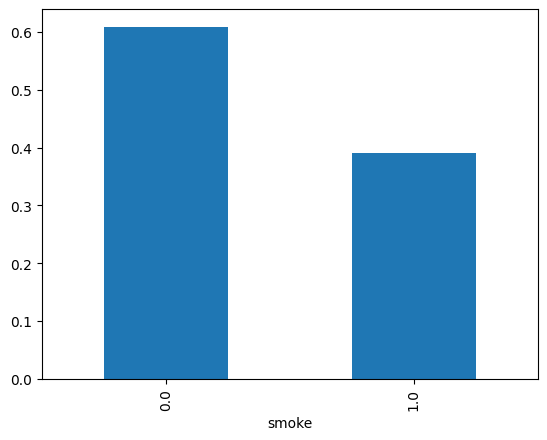

In [80]:
 # *Visualizing the distribution of the 'smoke' column in percentage  
df['smoke'].value_counts(normalize=True).plot(kind='bar')

In [81]:
df['parity'].unique()

array([0, 1])

In [82]:
df['parity'].value_counts()

parity
0    866
1    308
Name: count, dtype: int64

In [83]:
 #* correlation matrix
df.corr()

,bwt,gestation,parity,age,height,weight,smoke
bwt,1.000000,0.407543,-0.043908,0.026983,0.203704,0.155923,-0.246800
gestation,0.407543,1.000000,0.080916,-0.053425,0.070470,0.023655,-0.060267
parity,-0.043908,0.080916,1.000000,-0.351041,0.043543,-0.096362,-0.009599
age,0.026983,-0.053425,-0.351041,1.000000,-0.006453,0.147322,-0.067772
height,0.203704,0.070470,0.043543,-0.006453,1.000000,0.435287,0.017507
weight,0.155923,0.023655,-0.096362,0.147322,0.435287,1.000000,-0.060281
smoke,-0.246800,-0.060267,-0.009599,-0.067772,0.017507,-0.060281,1.000000


## **TRAINING AND TESTING DATA MODEL**

In supervised machine learning, the dataset is divided into **features (`X`)** and a **target (`y`)**. For example, in a birth-weight prediction problem, `gestation`, `age`, `weight`, and `smoke` are features (`X`), while `bwt` is the target (`y`). The data is split into **training** and **testing** sets using `train_test_split()`. During training, `model.fit(X_train, y_train)` learns the relationship between the features and the target. After learning, `model.predict(X_test)` uses only the unseen feature data (`X_test`) to generate predicted values (`y_pred`); it does not use `y_test` while predicting. Finally, the predicted values (`y_pred`) are compared with the actual values (`y_test`) using evaluation metrics such as **Mean Squared Error (MSE)** and **R² Score** to measure how well the model performs on unseen data. In short: **`fit()` learns patterns, `predict()` makes predictions, and evaluation compares those predictions with the real answers.**


In [84]:
 ## *splitting dataset into x and y
# *Where x represents independent label (bwt)
# *And y represents dependend label (other than bwt)

 # *WORKING: We train the model using X_train (gestation, age, weight, smoke, etc., independent/feature variable) and y_train (birth weight, dependent/target variable). Then we use X_test (new mothers the model hasn't seen before) to predict birth weight. Finally, we compare those predicted birth weights with the actual birth weights in y_test to see how accurate the model is. I

y=df['bwt']
x=df.iloc[:,1:]
print(x.head())
print()
print(y.head())


   gestation  parity   age  height  weight  smoke
0      284.0       0  27.0    62.0   100.0    0.0
1      282.0       0  33.0    64.0   135.0    0.0
2      279.0       0  28.0    64.0   115.0    1.0
4      282.0       0  23.0    67.0   125.0    1.0
5      286.0       0  25.0    62.0    93.0    0.0

0    120
1    113
2    128
4    108
5    136
Name: bwt, dtype: int64


In [85]:
 # *train test split
#* command : <pip install scikit-learn>

from sklearn.model_selection import train_test_split as tts

x_train, x_test, y_train, y_test=tts(x,y,test_size=0.20)


print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

print(x_train.count())
print(x_test.count())

print(y_train.count())
print(y_test.count())



(939, 6)
(235, 6)
(939,)
(235,)
gestation    939
parity       939
age          939
height       939
weight       939
smoke        939
dtype: int64
gestation    235
parity       235
age          235
height       235
weight       235
smoke        235
dtype: int64
939
235


In [86]:
 # * TRAINING THE DATA USING BELOW LINEAR MODELS

from sklearn.linear_model import LinearRegression, Lasso, Ridge

lr=LinearRegression()
ls=Lasso()
ri=Ridge()

In [87]:
lr.fit(x_train, y_train)
ls.fit(x_train, y_train)
ri.fit(x_train, y_train)


Ridge()

In [88]:
lr_pred=lr.predict(x_test)
ls_pred=ls.predict(x_test)
ri_pred=ri.predict(x_test)

## **MODEL EVALUATION**

EVALUATING DIFF B/W PREDICTION AND ACTUAL VALUES

In [90]:
from sklearn.metrics import r2_score, mean_squared_error

lr_r2=r2_score(y_test, lr_pred)
ls_r2=r2_score(y_test, ls_pred)
ri_r2=r2_score(y_test, ri_pred)

In [91]:
lr_mse=mean_squared_error(y_test, lr_pred)
ls_mse=mean_squared_error(y_test, ls_pred)
ri_mse=mean_squared_error(y_test, ri_pred)

In [94]:
print("\nPerformance of Linear Regression Model :")
print("R2score : ",lr_r2)
print("MSE : ",lr_mse)


print("\nPerformance of Lasso Regression Model :")
print("R2score : ",ls_r2)
print("MSE : ",ls_mse)


print("\nPerformance of Ridge Regression Model :")
print("R2score : ",ri_r2)
print("MSE : ",ri_mse)

  # * BASED ON ABOVE RESULT, WE SELECT LINEAR REGRESSION MODEL


Performance of Linear Regression Model :
R2score :  0.17447327096136178
MSE :  246.20362672290733

Performance of Lasso Regression Model :
R2score :  0.18181528660213753
MSE :  244.01395700703952

Performance of Ridge Regression Model :
R2score :  0.1746756158795838
MSE :  246.1432797335697


``` model = LinearRegression()

At this point, model is just an empty Linear Regression object. It knows how to learn, but it hasn't learned anything yet

If you inspect it:

model.coef_

You'll get an error because the model hasn't been trained. ```

After:

model.fit(X_train, y_train)

the same object is modified internally. Now it contains learned parameters such as:

model.coef_
model.intercept_

For example:

coef_ = [0.5, -2.1, 1.3]
intercept_ = 10.4

These values were learned from your training data.

i.e. WE SAVING THIS IN PIKLE FORMAT SO THAT WE WILL GET ALREADY TRAINED MODEL

In [96]:
 #* SAVING THE TRAINED MODEL IN PICKLE FORMAT

import pickle 


with open("model/model.pkl", 'wb') as f:
    pickle.dump(lr,f)

with open("model/model.pkl","wb") as f:
    pickle.dump(lr,f)

In [97]:
 #* LOAD THE SAVED MODEL

with open("model/model.pkl", "rb") as obj:
  mymodel=pickle.load(obj)

In [ ]:
 #* NEW DATA FOR TESTING THE MODEL
  
test_data = {
    "gestation":[302.0],	
    "parity" : [1]	,
    "age":[22.0],
    "height":[70.0],	
    "weight":[170.0],
    "smoke":[1.0]
}

test_data

{'gestation': [302.0],
 'parity': [1],
 'age': [22.0],
 'height': [70.0],
 'weight': [170.0],
 'smoke': [1.0]}

In [104]:
test_df=pd.DataFrame(test_data)

mymodel.predict(test_df)

array([132.48462005])